In [10]:
import numpy as np, json, os, matplotlib.pyplot as plt
from matplotlib import figure

In [11]:
# loads the /runs folder and parse through
results = {}

for name in (os.listdir("runs")):
    if not name.endswith(".json"):
        continue

    arm, task, s = name[:-5].split("_")
    seed = int(s[1:])

    with open(os.path.join("runs", name)) as f:
        results[(arm, task, seed)]=json.load(f)

print(len(results))

204


In [12]:
# check one run
r=results[("objective", "tower", 0)]

print(r["config"],"len: ",len(r["config"]))
print(r.keys(),"len: ",len(r.keys()))
print(len(r["gen_mean"]))

{'grid_shape': [24, 8, 12], 'population_size': 50, 'score_func': 'tower_score', 'seed': 0, 'agent_class': 'Agent', 'selection': 'objective', 'steps': 40, 'sigma': 0.002, 'generations': 200} len:  9
dict_keys(['config', 'gen_best', 'best_so_far', 'gen_mean', 'best_blocks', 'archive_size', 'rho_min']) len:  7
200


In [13]:
# best and plateau

best={}
plateau={}

for (arm, task, seed), r in results.items():
    b = r["best_so_far"][-1]
    p = np.mean(r["gen_mean"][-50:])
    best.setdefault((arm,task), []).append(b)
    plateau.setdefault((arm,task),[]).append(p)

print(len(best[("blend","bridge")]),len(best[("blend","tower")]))


30 10


In [14]:
# cliffs delta, -1 to 1, above 0 means that a tends to be higher than b

def cliffs_delta(a,b):
    counter=0
    for x in a:
        for y in b:
            if x > y:
                counter+=1
            elif y > x:
                counter -=1
    return counter / (len(a) * len(b))

print(cliffs_delta(plateau[("blend","bridge")], plateau[("objective","bridge")]))


0.015555555555555555


In [15]:
# permutation p value, how often random labels give delta at least as big
def permutation_test(a, b,n=10000):
    real=cliffs_delta(a, b)
    all_values=np.array(a+b)
    rng = np.random.default_rng(0)
    counter=0
    for i in range(n):
        shuffled=rng.permutation(all_values)
        test_a=shuffled[:len(a)]
        test_b=shuffled[len(a):]
        new_test_d = cliffs_delta(test_a,test_b)

        if abs(new_test_d) >= abs(real):
            counter+=1

    return real,(counter/n)

print(permutation_test(plateau[("blend","bridge")], plateau[("objective","bridge")]))

(0.015555555555555555, 0.9252)


In [16]:
# compare all runs

search_pairs = [("blend","objective"),("blend", "novelty"),("novelty","objective"), ("objective", "random"), ("noveltysplit","novelty"), ("blendsplit", "blend"), ("blendsplit", "objective"), ("noveltysplit", "objective")]
task_pairs = ["bridge","tower"]

for task in task_pairs:
    for a,b in search_pairs:
        if (a, task) not in best or (b, task) not in best:
            continue
        d_best, p_best = permutation_test(best[(a, task)], best[(b,task)])

        d_plat, p_plat = permutation_test(plateau[(a, task)], plateau[(b, task)])

        print(f"{task} {a} vs {b}  best d={round(d_best, 2)} p={round(p_best, 3)}  plateau d={round(d_plat, 2)} p={round(p_plat, 3)}")


bridge blend vs objective  best d=0.38 p=0.008  plateau d=0.02 p=0.925
bridge blend vs novelty  best d=0.34 p=0.018  plateau d=0.99 p=0.0
bridge novelty vs objective  best d=0.14 p=0.325  plateau d=-0.89 p=0.0
bridge objective vs random  best d=-0.14 p=0.512  plateau d=1.0 p=0.0
bridge noveltysplit vs novelty  best d=0.0 p=1.0  plateau d=0.18 p=0.224
bridge blendsplit vs blend  best d=0.14 p=0.346  plateau d=0.08 p=0.593
bridge blendsplit vs objective  best d=0.49 p=0.001  plateau d=0.07 p=0.647
bridge noveltysplit vs objective  best d=0.14 p=0.32  plateau d=-0.85 p=0.0
tower blend vs objective  best d=0.2 p=0.468  plateau d=0.04 p=0.908
tower blend vs novelty  best d=0.3 p=0.201  plateau d=1.0 p=0.0
tower novelty vs objective  best d=-0.12 p=0.722  plateau d=-0.96 p=0.0
tower objective vs random  best d=0.98 p=0.0  plateau d=1.0 p=0.0


(30, 200)


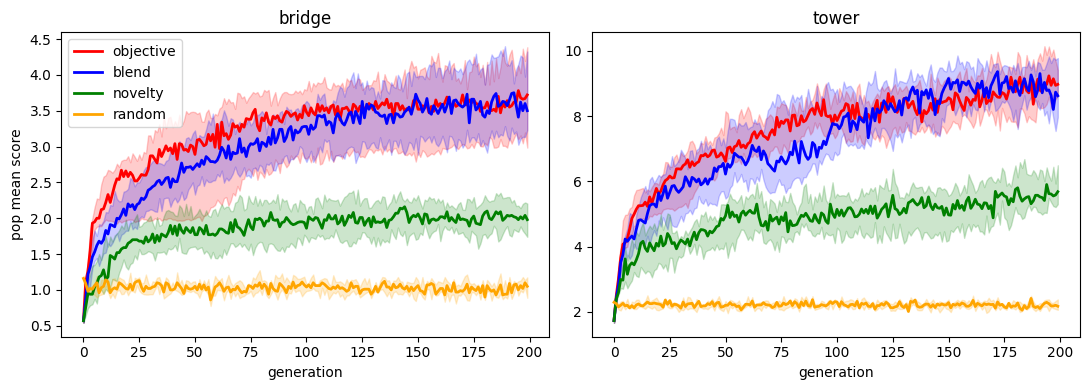

In [18]:
# mean reach per gen, median and spread across seed
curves={}
for (arm,task,seed),r in results.items():
    curves.setdefault((arm, task),[]).append(r["gen_mean"])

print(np.array(curves["blend", "bridge"]).shape)

colors = {"objective": "red", "blend": "blue", "novelty": "green", "random": "orange"}

fig,axes = plt.subplots(1,2,figsize=(11, 4))

for ax, task in zip(axes, ["bridge", "tower"]):
    for arm in colors:
        c= np.array(curves[(arm, task)])
        median = np.median(c, axis=0)
        lo, hi = np.percentile(c, [25, 75], axis=0)
        ax.plot(median, color=colors[arm], linewidth=2, label=arm)
        ax.fill_between(range(len(median)), lo, hi, color=colors[arm], alpha=0.2)
    ax.set_title(task)
    ax.set_xlabel("generation")


axes[0].set_ylabel("pop mean score")
axes[0].legend()

plt.tight_layout()
plt.show()

plt.style.use("default")



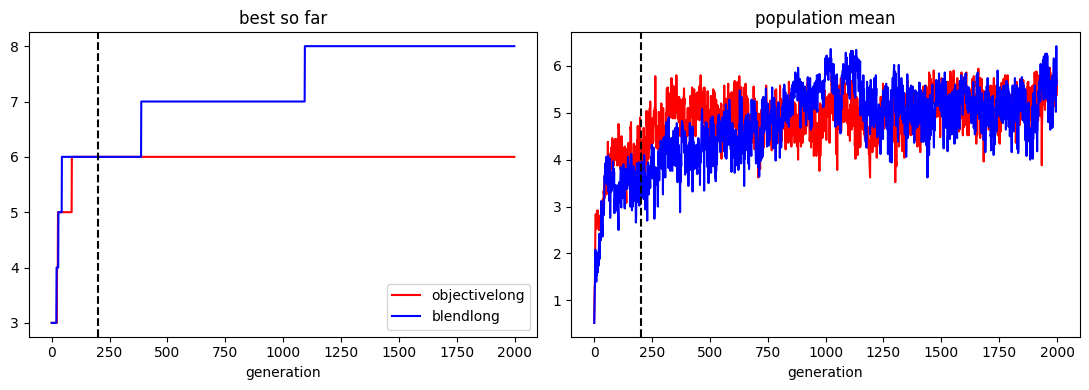

In [19]:
# specific long run comparison

fig, axes = plt.subplots(1,2,figsize=(11,4))

cs={"objectivelong":"red", "blendlong":"blue"}

for arm in cs:
    r=results[(arm, "bridge",0)]

    axes[0].plot(r["best_so_far"], color=cs[arm], label=arm)
    axes[1].plot(r["gen_mean"], color=cs[arm], label=arm)

axes[0].set_title("best so far")
axes[1].set_title("population mean")

axes[0].set_xlabel("generation")
axes[1].set_xlabel("generation")

axes[0].legend()

axes[0].axvline(200, color="black", linestyle="--" )
axes[1].axvline(200, color="black", linestyle="--")

plt.tight_layout()

plt.style.use("default")
plt.show()